In [2]:
import os
import numpy as np
import seaborn as sns
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt

In [4]:
path = os.path.abspath(os.getcwd())
file_path = os.path.join(os.path.dirname(path), "data", "rent_prediction.csv")

df = pd.read_csv(file_path)

df.head()

,IdentifiantMaison,Chambres,Salon,SalleDeBainInterieure,Parking,Meuble,Jardin,Superficie_m2,DistanceRoute_m,Quartier,AgeMaison,LoyerMensuel_BIF
0,1,4.0,Oui,Oui,NaN,Non,Oui,192.0,277.0,Rohero,17.0,2600000
1,2,5.0,Oui,Oui,Non,Oui,Non,234.0,47.0,Rohero,37.0,2600000
2,3,3.0,Oui,Oui,Non,Non,Oui,151.0,45.0,Kinanira,23.0,1069218
3,4,5.0,Oui,Oui,Oui,Oui,Oui,227.0,174.0,Gasekebuye,22.0,2600000
4,5,5.0,Oui,Oui,Oui,NaN,Non,262.0,216.0,Gihosha,21.0,2085458


### Dimensions, colonnes et types

In [6]:
numeric_cols = list(df.drop("IdentifiantMaison", axis=1).select_dtypes(include=["number"]).columns)
category_cols = list(df.drop("IdentifiantMaison", axis=1).select_dtypes(include=["object", "str"]).columns)

print(f"Colonnes dans les données : {list(df.columns)}")
print()
print(f"La forme de données du DataSet : {df.shape}")
print()
print(f"Type de données du DataSet : {df.info()}")

Colonnes dans les données : ['IdentifiantMaison', 'Chambres', 'Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin', 'Superficie_m2', 'DistanceRoute_m', 'Quartier', 'AgeMaison', 'LoyerMensuel_BIF']

La forme de données du DataSet : (510, 12)

<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IdentifiantMaison      510 non-null    int64  
 1   Chambres               485 non-null    float64
 2   Salon                  485 non-null    str    
 3   SalleDeBainInterieure  485 non-null    str    
 4   Parking                485 non-null    str    
 5   Meuble                 485 non-null    str    
 6   Jardin                 485 non-null    str    
 7   Superficie_m2          485 non-null    float64
 8   DistanceRoute_m        485 non-null    float64
 9   Quartier               485 non-null    str    
 10  AgeMaison              4

### Premier coup d'oeil aux données

In [8]:
df.head()
df.tail()
df.sample(10)

,IdentifiantMaison,Chambres,Salon,SalleDeBainInterieure,Parking,Meuble,Jardin,Superficie_m2,DistanceRoute_m,Quartier,AgeMaison,LoyerMensuel_BIF
116,117,1.0,Oui,Oui,Oui,Non,Non,37.0,91.0,Cibitoke,23.0,405293
118,119,1.0,Oui,Oui,Non,Non,Non,43.0,164.0,Kinanira,26.0,476807
403,404,4.0,Oui,Non,Non,Non,NaN,174.0,246.0,Nyakabiga,NaN,978257
391,392,3.0,Oui,Oui,Oui,Non,Non,115.0,214.0,Kinanira,34.0,1137214
185,186,4.0,Oui,Non,Oui,Oui,Non,197.0,121.0,Kinama,36.0,902442
206,207,4.0,Oui,Oui,Non,Oui,Non,186.0,52.0,Kamenge,21.0,1016783
462,463,5.0,Oui,Oui,Oui,Non,Non,235.0,277.0,Buyenzi,34.0,741104
365,366,5.0,Oui,Oui,Oui,Non,Oui,218.0,65.0,Musaga,25.0,1326405
78,79,4.0,Oui,Oui,Oui,Non,Non,215.0,88.0,Nyakabiga,2.0,1274350
452,453,3.0,Non,Oui,Oui,Non,Oui,157.0,227.0,Bwiza,NaN,569075


### Statistiques descriptives

In [9]:
df.describe()
# df.describe(include=["object"])

,IdentifiantMaison,Chambres,Superficie_m2,DistanceRoute_m,AgeMaison,LoyerMensuel_BIF
count,510.000000,485.000000,485.000000,485.000000,485.000000,5.100000e+02
mean,255.500000,3.521649,168.587629,154.637113,19.934021,1.244608e+06
std,147.368586,1.707436,79.464914,85.262406,11.544729,7.004331e+05
min,1.000000,1.000000,30.000000,6.000000,0.000000,1.361490e+05
25%,128.250000,2.000000,103.000000,76.000000,10.000000,6.999250e+05
50%,255.500000,4.000000,171.000000,154.000000,20.000000,1.082640e+06
75%,382.750000,5.000000,235.000000,226.000000,30.000000,1.680108e+06
max,510.000000,6.000000,320.000000,300.000000,40.000000,2.600000e+06


### Identification de valeurs maquantes

In [15]:
df.isnull()
df.isnull().sum().sort_values(ascending=False)

rooms              25
living_room        25
indoor_bathroom    25
Meuble             25
Jardin             25
Superficie_m2      25
dstance_to_road    25
Quartier           25
house_age          25
parking            24
monthly_rent        1
house_id            0
dtype: int64

### Lignes en double

In [17]:
df.duplicated()
df.duplicated().sum()

0      False
1      False
2      False
3      False
4      False
       ...  
505    False
506    False
507    False
508    False
509    False
Length: 510, dtype: bool

### Analyse de la cible

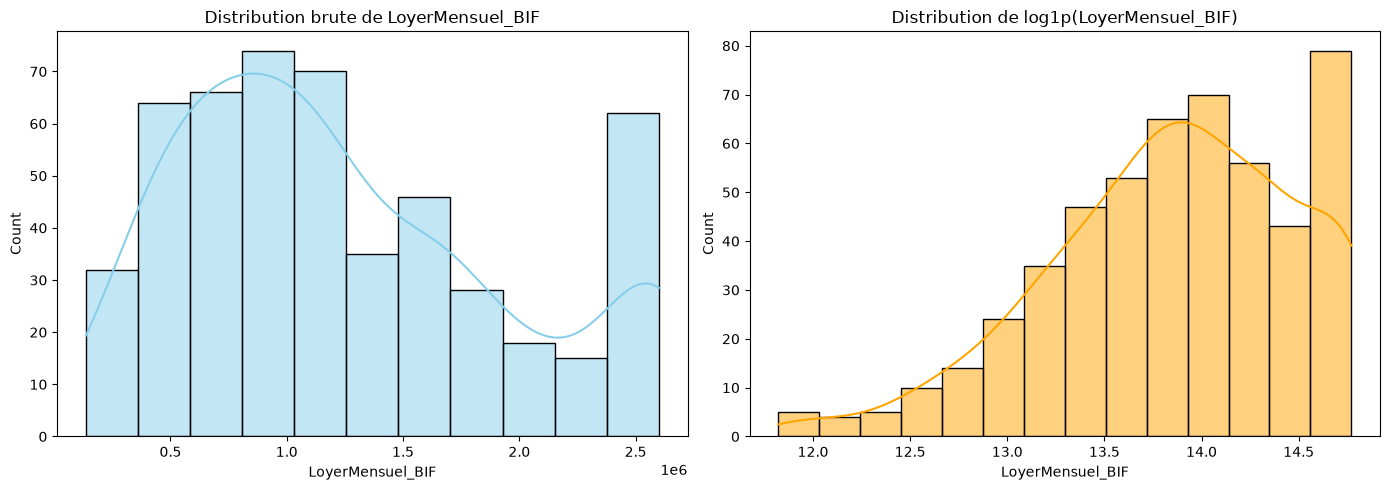

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["LoyerMensuel_BIF"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution brute de LoyerMensuel_BIF")

# Distribution avec Transformation Log
sns.histplot(np.log1p(df["LoyerMensuel_BIF"]), kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution de log1p(LoyerMensuel_BIF)")

plt.tight_layout()
plt.show()

### Analyses de features numériques

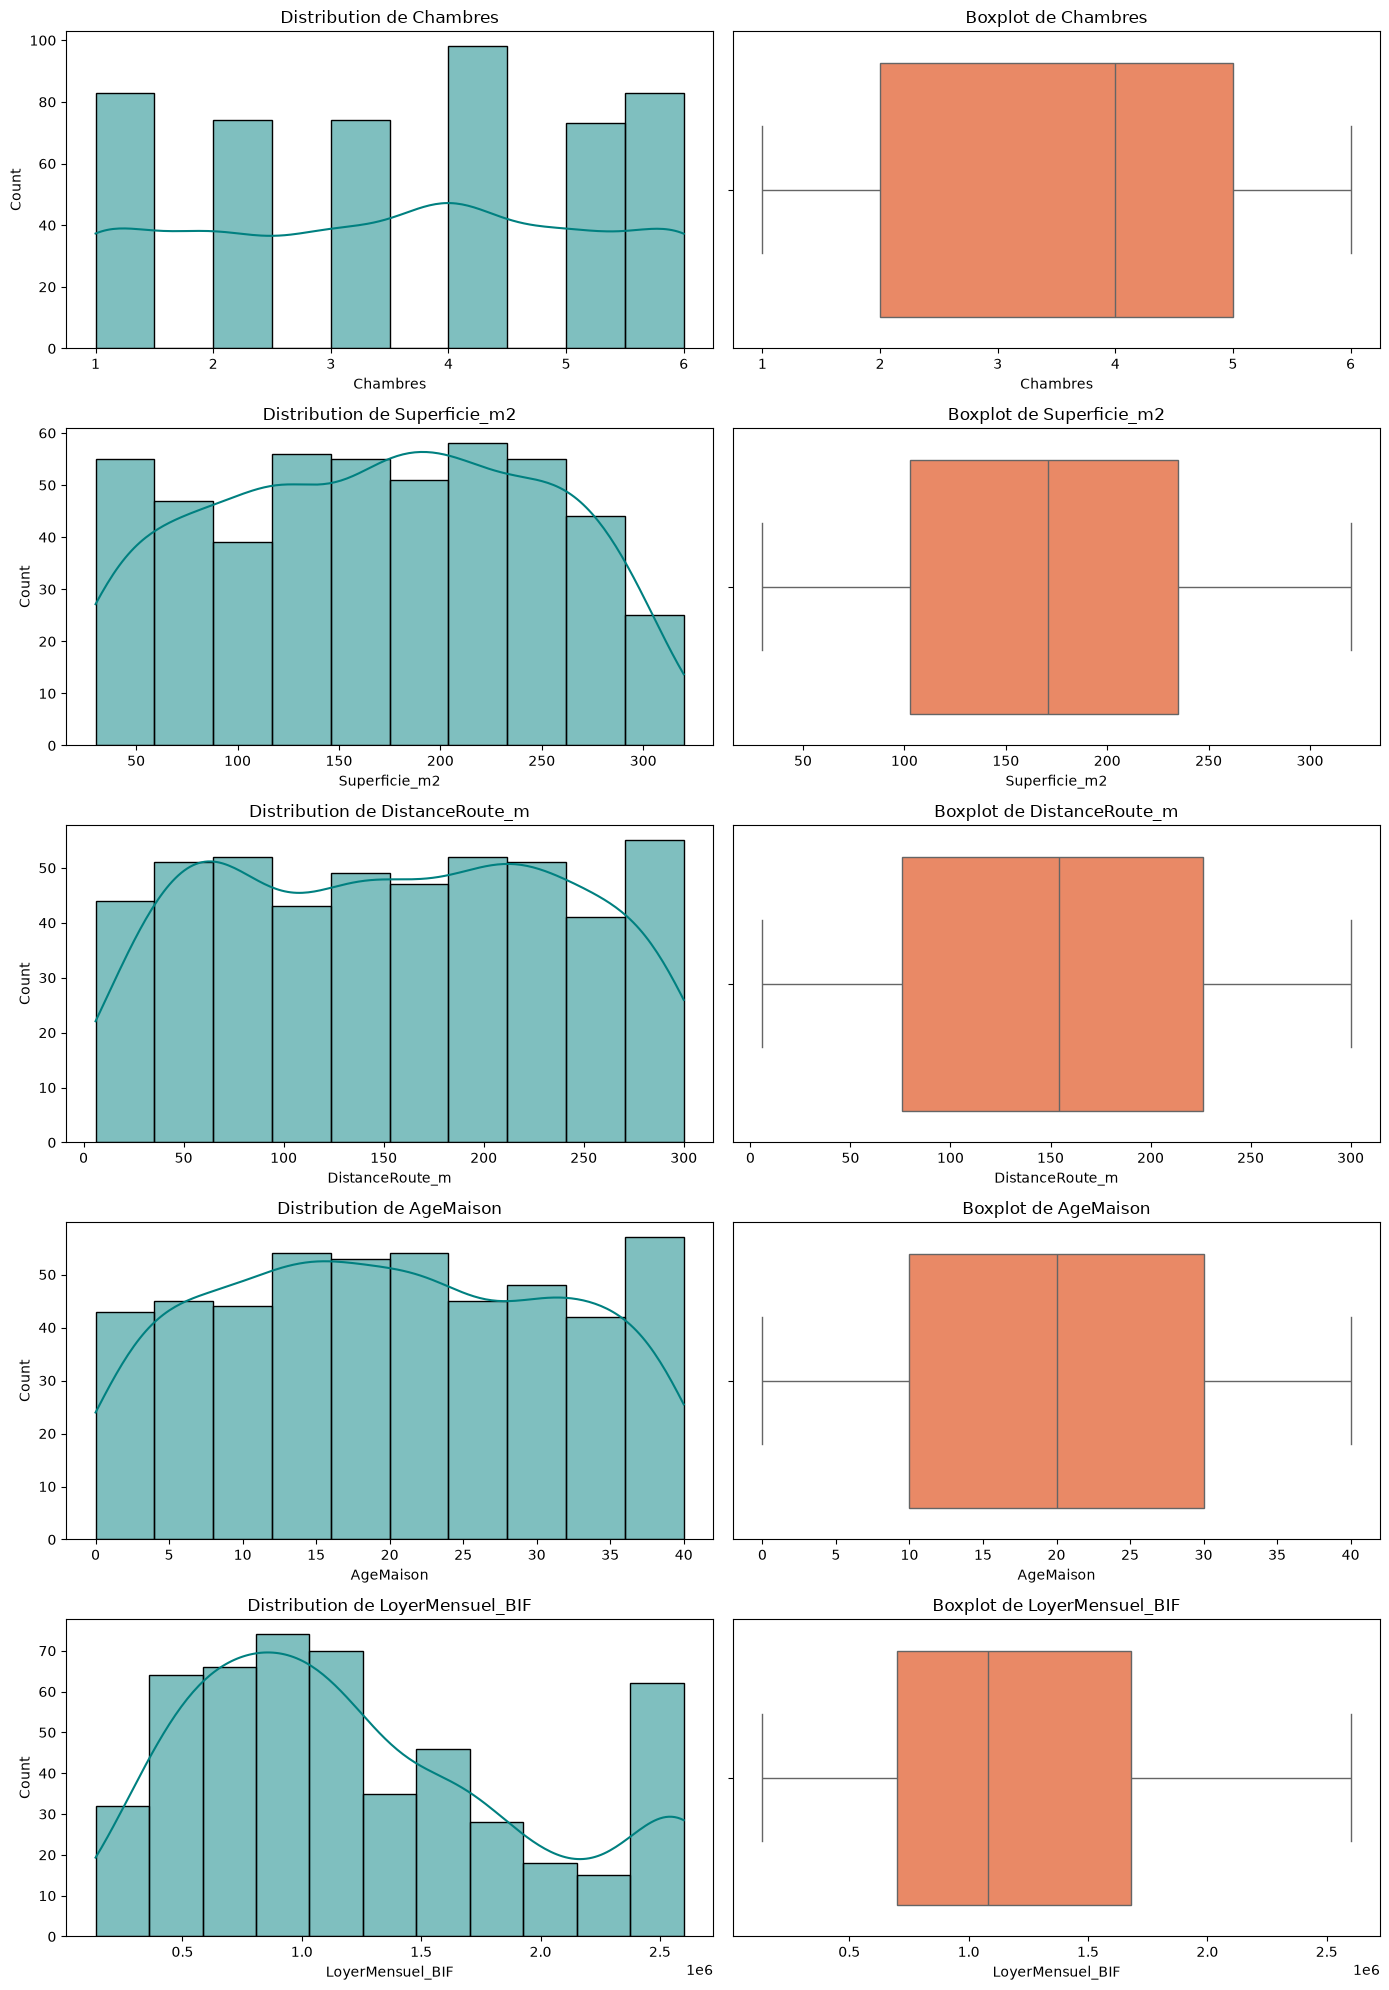

In [29]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="teal")
    axes[i, 0].set_title(f"Distribution de {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="coral")
    axes[i, 1].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

### Analyses de variables catégorielles

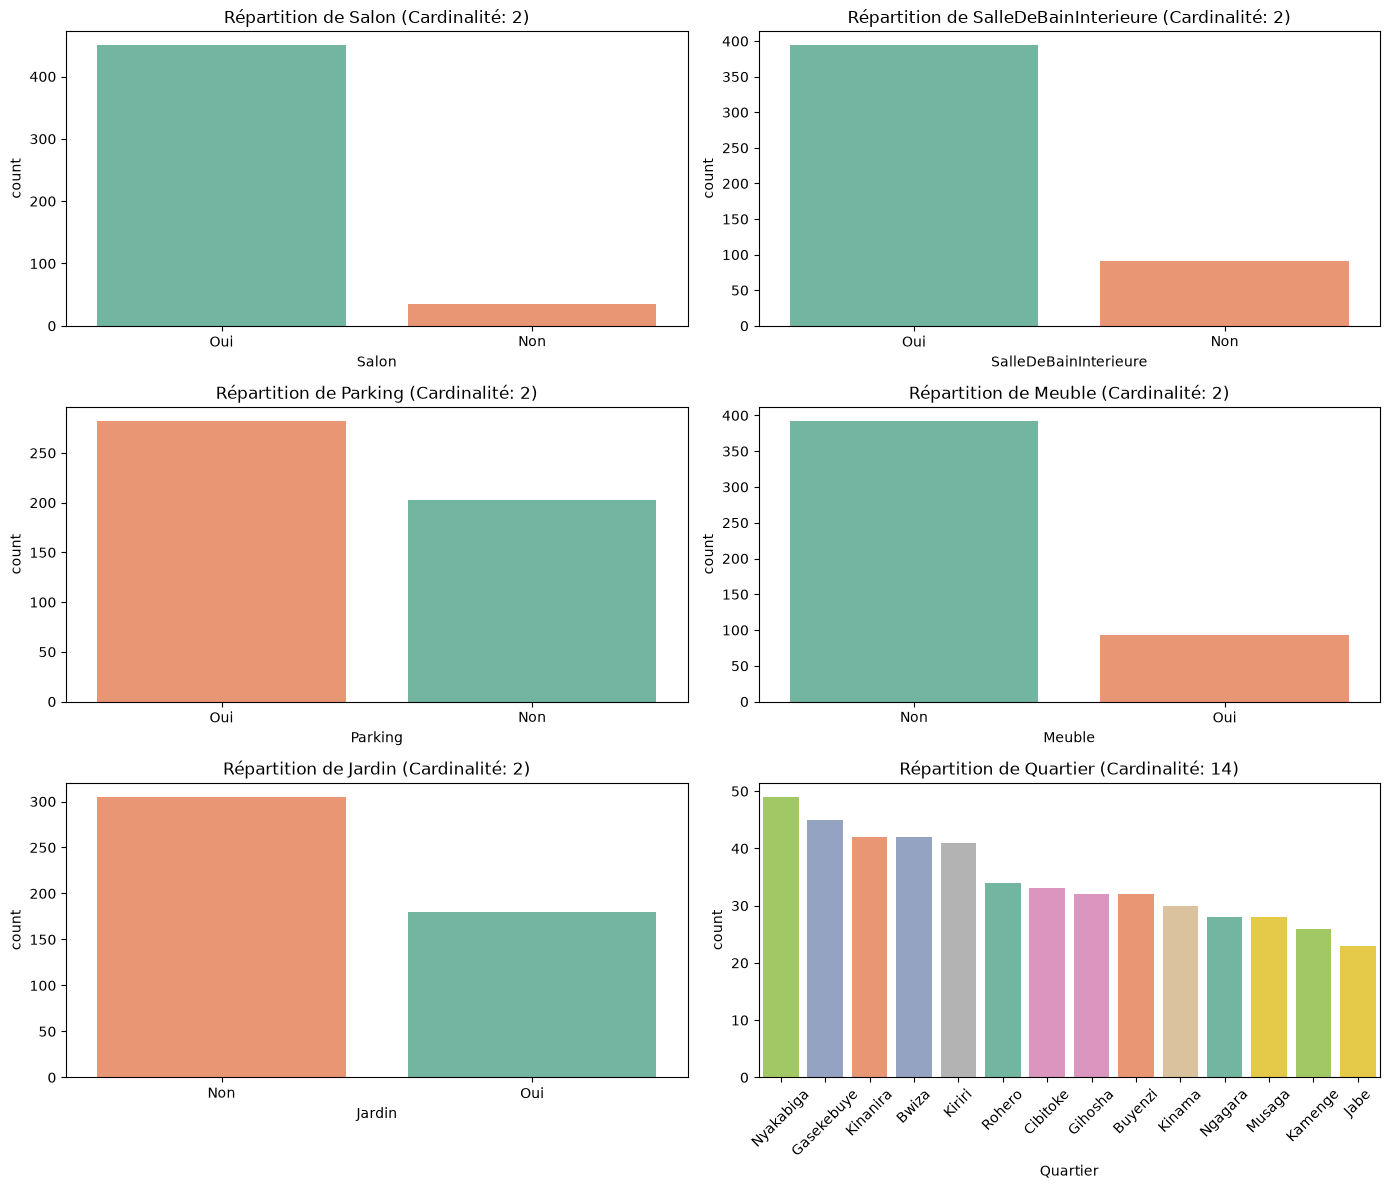

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(category_cols):
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        ax=axes[i],
        palette="Set2",
        order=df[col].value_counts().index,
    )
    axes[i].set_title(f"Répartition de {col} (Cardinalité: {df[col].nunique()})")
    axes[i].tick_params(axis="x", rotation=45 if df[col].nunique() > 5 else 0)

plt.tight_layout()
plt.show()

In [22]:
"""
  Calcule le V de Cramer entre deux variables catégorielles x et y

"""

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    # La formule de v de crammer
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

for col in category_cols:
    corr = cramers_v(df[col], df["LoyerMensuel_BIF"])
    print(col, "-->", corr)

Salon --> 0.31851102863530345
SalleDeBainInterieure --> 0.29702659618176697
Parking --> 0.12865483927056973
Meuble --> 0.0
Jardin --> 0.09168637698442861
Quartier --> 0.2244877131898931


### Pattern des valeurs maquantes

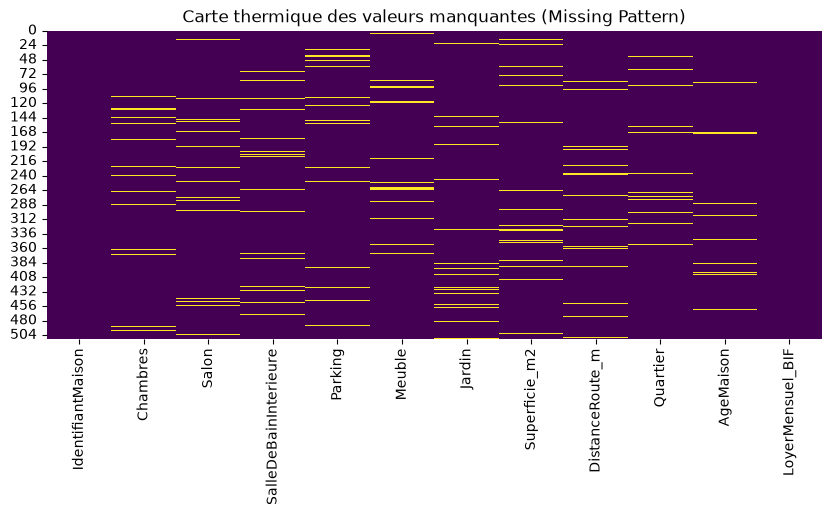

In [56]:
# Visualiser si les manques sont corrélés entre eux (MCAR vs MNAR)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Carte thermique des valeurs manquantes (Missing Pattern)")
plt.show()

### Corrélation avec la variable cible (LoyerMensuel_BIF)

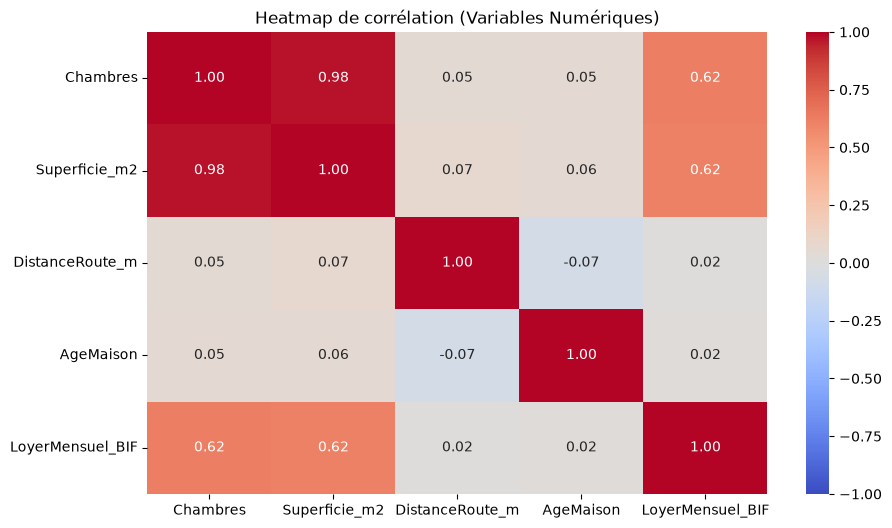

In [10]:
plt.figure(figsize=(10, 6))

corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Heatmap de corrélation (Variables Numériques)")
plt.show()

### Scatter plots / Boxplots croisant chaque feature avec LoyerMensuel_BIF.

In [ ]:
# Scatter plots pour les variables numériques
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(
        data=df, x=col, y="LoyerMensuel_BIF", alpha=0.6, color="indigo"
    )
    plt.title(f"{col} vs LoyerMensuel_BIF")
    plt.show()

# Boxplots pour les variables catégorielles
for col in category_cols:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        y="LoyerMensuel_BIF",
        palette="Pastel1",
        order=df.groupby(col)["LoyerMensuel_BIF"]
        .median()
        .sort_values(ascending=False)
        .index,
    )
    
    plt.title(f"LoyerMensuel_BIF selon {col}")
    plt.xticks(rotation=45 if df[col].nunique() > 5 else 0)
    plt.show()

In [2]:
# import pandas as pd

# eda_decisions_data = {
#     "Variable / Aspect": [
#         "Lignes Manquantes (Global)",
#         "AgeMaison",
#         "LoyerMensuel_BIF (Variable Cible)",
#         "Chambres & Superficie_m2",
#         "Quartier",
#         "Équipements (Meuble, Jardin, Salon, SdB)",
#         "DistanceRoute_m",
#         "Parking",
#     ],
#     "Données Observées (EDA)": [
#         "25 lignes totalement vides sur l'ensemble des features (485 non-nulls sur 510)[cite: 1].",
#         "Valeur maximale aberrante à 2 600 000 ans (fuite possible de la valeur du loyer)[cite: 1].",
#         "Distribution asymétrique à droite + effet de plafonnement/seuil marqué à 2 600 000 BIF[cite: 1].",
#         "Corrélation quasi-parfaite de 0.98 entre les deux variables + corrélation de 0.62 avec le loyer[cite: 1].",
#         "Forte hiérarchie des prix : Rohero/Kiriri très élevés vs Buyenzi/Bwiza très bas[cite: 1].",
#         "Impact positif net sur le loyer médian (notamment le caractère Meublé)[cite: 1].",
#         "Très faible corrélation linéaire avec le loyer (~0.02)[cite: 1].",
#         "Faible différenciation sur la distribution des loyers entre Oui et Non[cite: 1].",
#     ],
#     "Action / Décision Technique": [
#         "Suppression directe des 25 lignes concernées.",
#         "Remplacement des valeurs > 100 par NaN puis imputation par la médiane selon le Quartier.",
#         "Passage de la cible au log (log1p) pour lisser l'asymétrie + test d'un modèle adapté aux données censurées.",
#         "Conservation de Superficie_m2 pour modèles linéaires (ou création du ratio Superficie/Chambre) ; conservation des deux pour arbres/XGBoost.",
#         "Application d'un Target Encoding (ou Ordinal Encoding basé sur le loyer médian).",
#         "Création d'une feature composite 'Standing_Score' (somme des équipements présents).",
#         "Conservation temporaire ; test d'une binarisation (ex: Proche < 200m vs Éloigné) ou sélection par Ridge/Lasso.",
#         "Simplification ou faible pondération lors du Feature Engineering.",
#     ],
#     "Justification Technique": [
#         "Les données manquent simultanément sur tout le profil (MCAR/MAR), la suppression évite d'injecter du bruit sans perte d'information utile.",
#         "Corrige une erreur manifeste de saisie tout en préservant la cohérence géographique globale.",
#         "Rapproche la cible d'une distribution normale, ce qui stabilise la variance et améliore les performances des régresseurs.",
#         "Évite le problème de multicolinéarité sévère qui déstabilise les coefficients des modèles linéaires.",
#         "Conserve l'information spatiale et la valeur foncière sans exploser le nombre de dimensions (contrairement au One-Hot Encoding).",
#         "Synthétise le niveau de confort général du bien en une seule variable explicative puissante.",
#         "Transforme une variable continue peu explicative en un seuil de proximité plus pertinent.",
#         "Évite de surcharger les modèles avec des variables peu discriminantes.",
#     ],
# }

# # Création du DataFrame
# eda_decisions = pd.DataFrame(eda_decisions_data)

# pd.set_option("display.max_colwidth", None)
# eda_decisions

,Variable / Aspect,Données Observées (EDA),Action / Décision Technique,Justification Technique
0,Lignes Manquantes (Global),25 lignes totalement vides sur l'ensemble des features (485 non-nulls sur 510)[cite: 1].,Suppression directe des 25 lignes concernées.,"Les données manquent simultanément sur tout le profil (MCAR/MAR), la suppression évite d'injecter du bruit sans perte d'information utile."
1,AgeMaison,Valeur maximale aberrante à 2 600 000 ans (fuite possible de la valeur du loyer)[cite: 1].,Remplacement des valeurs > 100 par NaN puis imputation par la médiane selon le Quartier.,Corrige une erreur manifeste de saisie tout en préservant la cohérence géographique globale.
2,LoyerMensuel_BIF (Variable Cible),Distribution asymétrique à droite + effet de plafonnement/seuil marqué à 2 600 000 BIF[cite: 1].,Passage de la cible au log (log1p) pour lisser l'asymétrie + test d'un modèle adapté aux données censurées.,"Rapproche la cible d'une distribution normale, ce qui stabilise la variance et améliore les performances des régresseurs."
3,Chambres & Superficie_m2,Corrélation quasi-parfaite de 0.98 entre les deux variables + corrélation de 0.62 avec le loyer[cite: 1].,Conservation de Superficie_m2 pour modèles linéaires (ou création du ratio Superficie/Chambre) ; conservation des deux pour arbres/XGBoost.,Évite le problème de multicolinéarité sévère qui déstabilise les coefficients des modèles linéaires.
4,Quartier,Forte hiérarchie des prix : Rohero/Kiriri très élevés vs Buyenzi/Bwiza très bas[cite: 1].,Application d'un Target Encoding (ou Ordinal Encoding basé sur le loyer médian).,Conserve l'information spatiale et la valeur foncière sans exploser le nombre de dimensions (contrairement au One-Hot Encoding).
5,"Équipements (Meuble, Jardin, Salon, SdB)",Impact positif net sur le loyer médian (notamment le caractère Meublé)[cite: 1].,Création d'une feature composite 'Standing_Score' (somme des équipements présents).,Synthétise le niveau de confort général du bien en une seule variable explicative puissante.
6,DistanceRoute_m,Très faible corrélation linéaire avec le loyer (~0.02)[cite: 1].,Conservation temporaire ; test d'une binarisation (ex: Proche < 200m vs Éloigné) ou sélection par Ridge/Lasso.,Transforme une variable continue peu explicative en un seuil de proximité plus pertinent.
7,Parking,Faible différenciation sur la distribution des loyers entre Oui et Non[cite: 1].,Simplification ou faible pondération lors du Feature Engineering.,Évite de surcharger les modèles avec des variables peu discriminantes.
